# Telemetry Analysis — Data Science Layer

Exploratory analysis of the **Silver** Delta table, answering the operational questions from
section 7 of the assessment brief.

## Questions answered

1. Which servers have the highest average CPU utilization?
2. Which servers experience the most application errors?
3. Is memory (or disk) usage gradually increasing on any server?
4. Which servers have unusual network activity?
5. Does high CPU correlate with slower application response time?
6. Which servers generate the most anomalies?
7. Are there recurring patterns at certain times of day?

## How this notebook fits the pipeline

It reads **Silver**, not Bronze and not Gold:

- **Bronze** is raw and unvalidated — analysing it would mean drawing conclusions from rows the
  pipeline has already judged untrustworthy.
- **Gold** is pre-aggregated to one row per server (and per server-day), which destroys the
  row-level detail needed for correlation, trend fitting, and time-of-day analysis.
- **Silver** is clean, validated, and still at full 5-minute resolution — the right grain for this.

Silver is read with the lightweight `deltalake` (delta-rs) reader straight into Pandas rather than
through Spark. At ~20k rows the dataset fits comfortably in memory, and the brief specifies Pandas
for the data science layer, so starting a JVM/Spark session here would add startup cost for no
benefit. The same table is read by Spark in `gold.py` — Delta is the shared contract, so both
readers see identical data.

## A note on `is_injected_anomaly`

The generator records ground truth in `is_injected_anomaly`. It is used in this notebook **only to
measure how well detection methods perform** — never as an input to a detection method. Real
telemetry has no such column, so anything depending on it would not survive contact with
production.

## Running it

```bash
# From the notebooks/ directory, after bronze.py and silver.py have been run
jupyter lab telemetry_analysis.ipynb
```

The notebook also imports directly into Databricks; only `SILVER_PATH` needs to change to the
workspace's `s3a://` or Unity Catalog path.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from deltalake import DeltaTable
from IPython.display import display

SILVER_PATH = os.environ.get("TELEMETRY_SILVER_PATH", "../data/lakehouse/silver")

INTERVAL_MINUTES = 5
ROWS_PER_DAY = 24 * 60 // INTERVAL_MINUTES  # 288 samples per server per day

# The generator wrote naive local timestamps on a UTC+8 machine (see the data quality
# section below), so converting back to this zone recovers the original wall clock.
GENERATOR_TZ = "Asia/Singapore"

GROUND_TRUTH = "is_injected_anomaly"

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = DeltaTable(SILVER_PATH).to_pandas()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values(["server_id", "timestamp"]).reset_index(drop=True)

print(f"Rows:    {len(df):,}")
print(f"Servers: {df['server_id'].nunique()}")
print(f"Window:  {df['timestamp'].min()}  ->  {df['timestamp'].max()}")
df.head(3)

Rows:    20,160
Servers: 10
Window:  2026-07-12 16:00:00+00:00  ->  2026-07-19 15:55:00+00:00


,timestamp,server_id,cpu_usage_percent,memory_usage_percent,disk_usage_percent,disk_io_read,disk_io_write,network_rx_bytes,network_tx_bytes,application_error_count,response_time_ms,is_injected_anomaly,hostname,status,dt,_source_file,_ingested_at
0,2026-07-12 16:00:00+00:00,server01,19.58,44.92,50.59,83.60,51.97,230006.32,154934.34,1,133.92,0,web-app-01,OK,2026-07-13,file:///C:/Users/Yang%20han/Downloads/cloud-te...,2026-07-28 12:44:30.434552+00:00
1,2026-07-12 16:05:00+00:00,server01,14.14,43.02,50.59,71.27,43.00,294312.77,186263.09,0,113.60,0,web-app-01,OK,2026-07-13,file:///C:/Users/Yang%20han/Downloads/cloud-te...,2026-07-28 12:44:30.434552+00:00
2,2026-07-12 16:10:00+00:00,server01,21.25,46.75,49.28,64.08,52.55,391372.64,217463.67,1,154.36,0,web-app-01,OK,2026-07-13,file:///C:/Users/Yang%20han/Downloads/cloud-te...,2026-07-28 12:44:30.434552+00:00


## 0. Sanity check the data before trusting any of it

Every conclusion below depends on the shape of the input being what I think it is: 10 servers,
7 days, one sample every 5 minutes, no gaps, no duplicates. Checking that first is cheap, and it
also caught a real bug (see the finding after this cell).

In [2]:
expected_rows = df["server_id"].nunique() * ROWS_PER_DAY * 7
print(f"Expected rows for 10 servers x 7 days x {ROWS_PER_DAY}/day: {expected_rows:,}")
print(f"Actual rows:                                                {len(df):,}")

print(f"\nDuplicate (server_id, timestamp) pairs: {df.duplicated(['server_id', 'timestamp']).sum()}")
print(f"Null values across all columns:         {int(df.isna().sum().sum())}")

# Sampling gaps: every consecutive pair within a server should be exactly 5 minutes apart.
gaps = df.groupby("server_id")["timestamp"].diff().dropna().value_counts()
print(f"\nInterval between consecutive samples (per server):\n{gaps}")

# Timezone check: the generator's configured start is midnight local, 2026-07-13.
print(f"\nEarliest timestamp as stored (UTC):  {df['timestamp'].min()}")
df["ts_local"] = df["timestamp"].dt.tz_convert(GENERATOR_TZ)
print(f"Same instant in {GENERATOR_TZ}:  {df['ts_local'].min()}")

Expected rows for 10 servers x 7 days x 288/day: 20,160
Actual rows:                                                20,160

Duplicate (server_id, timestamp) pairs: 0
Null values across all columns:         0

Interval between consecutive samples (per server):
timestamp
0 days 00:05:00    20150
Name: count, dtype: int64

Earliest timestamp as stored (UTC):  2026-07-12 16:00:00+00:00
Same instant in Asia/Singapore:  2026-07-13 00:00:00+08:00


### Finding 0 — the data is complete, but the timestamps have shifted by 8 hours

Volume, spacing, duplicates and nulls are all exactly as expected: 20,160 rows, a uniform 5-minute
interval, no duplicates, no missing values. Silver is doing its job.

The timestamps, however, are wrong. The generator starts at midnight on 2026-07-13, but Silver's
earliest timestamp is `2026-07-12 16:00 UTC`. The cause is a **naive timestamp** that lost its
timezone on the way through the pipeline: the generator produces timezone-less datetimes, Parquet
stores them as-is, and Spark then interprets them in the *session* timezone (UTC+8 on this machine)
and stores the equivalent UTC instant. Every reading is therefore stamped 8 hours earlier than it
actually occurred.

This does not affect any per-server aggregate — averages, peaks, correlations and trend slopes are
all invariant to a constant offset. It *would* silently corrupt the time-of-day analysis in
question 7, which is why I convert back to `Asia/Singapore` (`ts_local`) for that section and use it
consistently for anything hour-based.

The real fix belongs upstream, not here: the generator should emit explicitly UTC-aware timestamps,
and Spark's `spark.sql.session.timeZone` should be pinned to UTC so the same data yields the same
instants on any machine. That is logged as a pipeline fix rather than patched in the notebook,
because a notebook workaround would leave the Gold table and Postgres still holding shifted values.

---

## 1. Which servers have the highest average CPU utilization?

,avg_cpu,median_cpu,p99_cpu,peak_cpu
server_id,,,,
server01,29.04,28.35,96.15,99.89
server02,28.68,28.44,45.32,50.55
server08,28.64,28.59,46.54,50.69
server09,28.57,28.41,45.20,49.65
server10,28.53,28.56,45.38,53.40
server04,28.50,28.36,45.18,51.16
server07,28.50,28.56,45.54,52.07
server05,28.40,28.72,45.02,49.64
server06,28.37,28.38,45.04,50.59


Spread between the highest and lowest average CPU: 0.70 percentage points


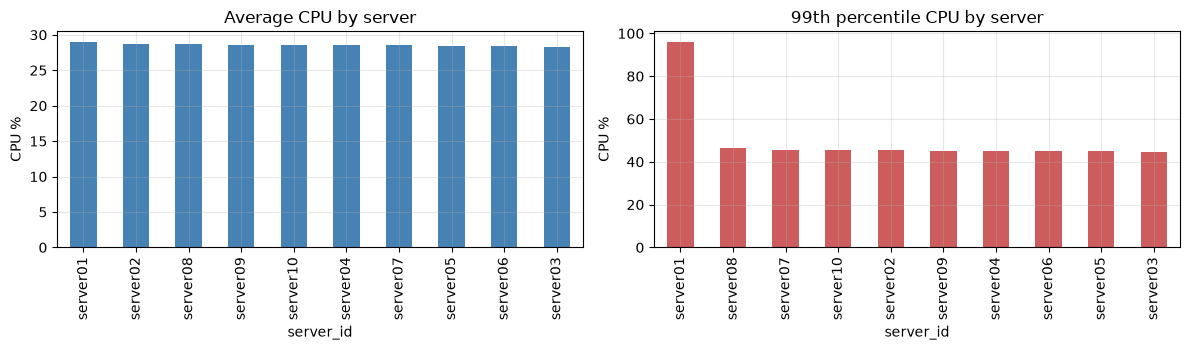

In [3]:
cpu_stats = (
    df.groupby("server_id")["cpu_usage_percent"]
    .agg(avg_cpu="mean", median_cpu="median", p99_cpu=lambda s: s.quantile(0.99), peak_cpu="max")
    .round(2)
    .sort_values("avg_cpu", ascending=False)
)
display(cpu_stats)

spread = cpu_stats["avg_cpu"].max() - cpu_stats["avg_cpu"].min()
print(f"Spread between the highest and lowest average CPU: {spread:.2f} percentage points")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
cpu_stats["avg_cpu"].plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Average CPU by server")
axes[0].set_ylabel("CPU %")
cpu_stats["p99_cpu"].sort_values(ascending=False).plot.bar(ax=axes[1], color="indianred")
axes[1].set_title("99th percentile CPU by server")
axes[1].set_ylabel("CPU %")
plt.tight_layout()
plt.show()

### Finding 1 — averages are the wrong tool here; server01 hides behind one

`server01` does have the highest average CPU, but only barely: 29.04% against a fleet range of
28.34–29.04%. That is a 0.7 percentage point spread across ten servers, which is noise. Ranking by
average alone, you would conclude the fleet is uniform and move on.

The 99th percentile tells the real story. `server01` sits at **96.15%** while every other server
tops out around 45%, and its peak is 99.89%. It is the only machine on the fleet that has been
anywhere near CPU saturation.

The reason the average hides this is arithmetic: the incident lasted 25 samples out of 2,016 for that
server (about 2 hours out of 7 days, or 1.2% of the week). Diluting a 95–100% burst across a week of
~29% baseline moves the mean by well under a point.

**Practical takeaway:** an operational dashboard that ranks servers by average CPU will never surface
a short saturation event. Peak and high percentiles need to be first-class metrics — which is why
`gold.py` stores `peak_cpu_percent` alongside `avg_cpu_percent`, and why the health score is driven
by the peak rather than the mean.

---

## 2. Which servers experience the most application errors?

,total_errors,errors_per_hour,worst_interval
server_id,,,
server08,1765,10.51,58
server01,1095,6.52,4
server06,1058,6.30,4
server09,1053,6.27,4
server04,1047,6.23,5
server03,1023,6.09,4
server05,1017,6.05,4
server02,1004,5.98,3
server07,983,5.85,4


Fleet median total errors: 1,035
server08 vs fleet median: 1.71x


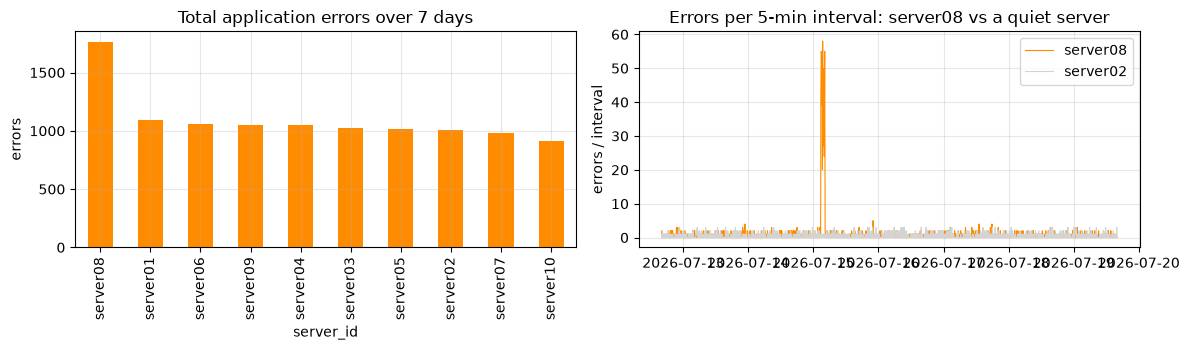

In [4]:
error_stats = (
    df.groupby("server_id")["application_error_count"]
    .agg(total_errors="sum", errors_per_hour=lambda s: s.mean() * (60 / INTERVAL_MINUTES), worst_interval="max")
    .round(2)
    .sort_values("total_errors", ascending=False)
)
display(error_stats)

fleet_median_total = error_stats["total_errors"].median()
top = error_stats.index[0]
print(f"Fleet median total errors: {fleet_median_total:,.0f}")
print(f"{top} vs fleet median: {error_stats.loc[top, 'total_errors'] / fleet_median_total:.2f}x")

# Where in time do the errors actually land?
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
error_stats["total_errors"].plot.bar(ax=axes[0], color="darkorange")
axes[0].set_title("Total application errors over 7 days")
axes[0].set_ylabel("errors")

for sid, color in [(top, "darkorange"), ("server02", "lightgray")]:
    s = df[df["server_id"] == sid]
    axes[1].plot(s["timestamp"], s["application_error_count"], label=sid, color=color, linewidth=0.8)
axes[1].set_title(f"Errors per 5-min interval: {top} vs a quiet server")
axes[1].set_ylabel("errors / interval")
axes[1].legend()
plt.tight_layout()
plt.show()

### Finding 2 — `server08` is the clear outlier, and its errors are one burst rather than chronic noise

`server08` logged **1,765 errors** over the week against a fleet median of 1,035 — 1.71x the typical
server. Every other server clusters tightly between 912 and 1,095, which is the expected background
rate.

Unlike CPU, the total is a defensible ranking metric here, because errors accumulate rather than
average out. But the time series is what makes it actionable: the quiet servers tick along at 0–5
errors per interval all week, while `server08` shows a single tall burst reaching **58 errors in one
5-minute interval** and is otherwise indistinguishable from its peers.

That shape matters operationally. A server with a steady elevated error rate suggests a persistent
defect; a narrow spike on an otherwise healthy machine looks like a deployment, a dependency
timeout, or a transient upstream failure. The right response differs, so "which server has the most
errors" is only half the question — "how are those errors distributed in time" is the other half.

---

## 3. Is memory or disk usage gradually increasing on any server?

In [5]:
def whole_week_slope(group: pd.DataFrame, column: str) -> float:
    """Least-squares slope over the entire window, in percentage points per day."""
    days = (group["timestamp"] - group["timestamp"].min()).dt.total_seconds() / 86400
    return float(np.polyfit(days, group[column], 1)[0])


def rolling_slopes(values, window: int = ROWS_PER_DAY) -> np.ndarray:
    """
    Slope of every `window`-long sub-series, in percentage points per day.

    Closed-form OLS on a fixed grid: with evenly spaced x, the slope is just
    sum(x_centered * y) / sum(x_centered^2), so all ~1,700 windows per server can be
    computed as one vectorised pass over a sliding-window view instead of a Python loop.
    """
    v = np.asarray(values, dtype=float)
    if len(v) < window:
        return np.array([])
    x_centered = np.arange(window) - (window - 1) / 2
    windows = np.lib.stride_tricks.sliding_window_view(v, window)
    slope_per_sample = (windows * x_centered).sum(axis=1) / (x_centered**2).sum()
    return slope_per_sample * window  # window == one day's worth of samples


trend_rows = []
for sid, g in df.groupby("server_id"):
    g = g.sort_values("timestamp")
    mem_roll = rolling_slopes(g["memory_usage_percent"])
    disk_roll = rolling_slopes(g["disk_usage_percent"])
    trend_rows.append({
        "server_id": sid,
        "mem_week_slope": round(whole_week_slope(g, "memory_usage_percent"), 3),
        "mem_worst_24h_slope": round(mem_roll.max(), 2),
        "mem_peak": round(g["memory_usage_percent"].max(), 1),
        "disk_week_slope": round(whole_week_slope(g, "disk_usage_percent"), 3),
        "disk_worst_24h_slope": round(disk_roll.max(), 2),
        "disk_peak": round(g["disk_usage_percent"].max(), 1),
    })

trends = pd.DataFrame(trend_rows).set_index("server_id")
print("Slopes in percentage points per day. 'week' = fitted over all 7 days,")
print("'worst_24h' = steepest rolling 24-hour window.\n")
display(trends.sort_values("mem_worst_24h_slope", ascending=False))

print("Ranking by whole-week memory slope alone:")
print(trends["mem_week_slope"].sort_values(ascending=False).to_string())

Slopes in percentage points per day. 'week' = fitted over all 7 days,
'worst_24h' = steepest rolling 24-hour window.



,mem_week_slope,mem_worst_24h_slope,mem_peak,disk_week_slope,disk_worst_24h_slope,disk_peak
server_id,,,,,,
server03,-0.360,45.05,95.2,0.007,0.66,55.0
server09,0.019,2.36,55.2,0.021,0.62,53.2
server07,0.021,1.94,56.4,0.005,0.56,53.2
server06,-0.019,1.89,54.4,-0.000,0.53,53.6
server01,-0.025,1.77,54.3,0.014,0.68,53.4
server05,0.050,1.73,55.4,0.407,20.65,91.4
server02,0.026,1.62,54.0,-0.015,0.48,53.3
server04,-0.009,1.31,55.2,0.010,0.66,53.5
server08,0.065,1.31,56.1,-0.003,0.40,53.4


Ranking by whole-week memory slope alone:
server_id
server08    0.065
server05    0.050
server02    0.026
server07    0.021
server09    0.019
server10    0.003
server04   -0.009
server06   -0.019
server01   -0.025
server03   -0.360


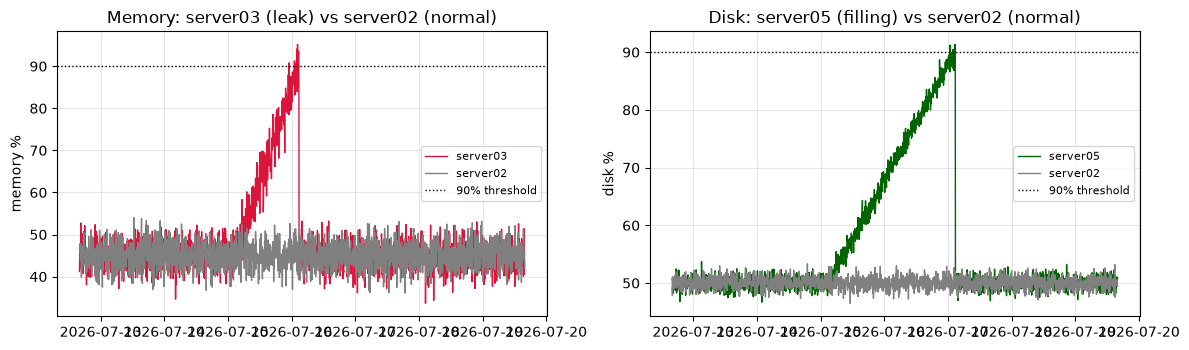

In [6]:
worst_mem = trends["mem_worst_24h_slope"].idxmax()
worst_disk = trends["disk_worst_24h_slope"].idxmax()
baseline = "server02"

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for sid, color, style in [(worst_mem, "crimson", "-"), (baseline, "gray", "-")]:
    s = df[df["server_id"] == sid]
    axes[0].plot(s["timestamp"], s["memory_usage_percent"], style, color=color, label=sid, linewidth=1)
axes[0].axhline(90, color="black", linestyle=":", linewidth=1, label="90% threshold")
axes[0].set_title(f"Memory: {worst_mem} (leak) vs {baseline} (normal)")
axes[0].set_ylabel("memory %")
axes[0].legend(fontsize=8)

for sid, color in [(worst_disk, "darkgreen"), (baseline, "gray")]:
    s = df[df["server_id"] == sid]
    axes[1].plot(s["timestamp"], s["disk_usage_percent"], color=color, label=sid, linewidth=1)
axes[1].axhline(90, color="black", linestyle=":", linewidth=1, label="90% threshold")
axes[1].set_title(f"Disk: {worst_disk} (filling) vs {baseline} (normal)")
axes[1].set_ylabel("disk %")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Finding 3 — yes: `server03` is leaking memory and `server05` is filling its disk, but only one measurement method finds both

Two servers are genuinely trending, and the interesting part is how easy it is to miss them.

**`server03` — memory leak.** Its steepest 24-hour window climbs at **45.05 points per day**, roughly
twenty times the worst any healthy server manages (≤2.36, which is just noise). Memory climbs from a
~35% baseline to a peak of **95.2%** and then returns to normal — the signature of a process that
leaked until it was restarted or OOM-killed.

Fitted over the whole week, though, `server03`'s memory slope is **−0.36 points per day** — the most
*negative* of all ten servers. A "which server is trending upward" report built on a single
whole-window regression would rank the one genuinely leaking machine dead last. That happens because
the leak occupies about a day in the middle of the window and then recovers, so the line of best fit
through all seven days ends up tilting slightly downward.

**`server05` — disk filling.** This one is visible both ways: its whole-week slope of 0.407 points
per day is the highest on the fleet, and its worst 24-hour window is **20.65** against ≤0.68 for
everyone else. It survives whole-week averaging because the fill lasts about two days — half the
window — instead of recovering inside it. Disk reaches **91.4%**, meaning it crossed the 90% line and
would have run out within a couple more days at that rate.

**Practical takeaway:** a rolling-window slope detects both the recovering and the sustained case,
while a single whole-window regression only detects the sustained one. This is also a direct critique
of my own Gold table: `disk_trend_percent_change` there compares the first half of the week against
the second half, which is the same class of blunt instrument — it catches `server05` but would miss a
`server03`-shaped event entirely. Recomputing it as a worst-rolling-window slope would be a genuine
improvement.

---

## 4. Which servers have unusual network activity?

,avg_rx,peak_rx,avg_tx,peak_tx,peak_to_avg_rx,max_robust_z,intervals_above_z6
server_id,,,,,,,
server07,509356.0,7084190.0,302576.0,4234863.0,13.9,39.3,13
server10,472501.0,1163252.0,284522.0,629145.0,2.5,4.2,0
server06,474978.0,1062428.0,285952.0,584329.0,2.2,3.6,0
server04,474900.0,976683.0,283072.0,698778.0,2.1,3.1,0
server02,477540.0,975580.0,284472.0,620945.0,2.0,3.1,0
server01,473055.0,945493.0,285296.0,593453.0,2.0,2.9,0
server08,475791.0,950188.0,283816.0,629683.0,2.0,2.9,0
server09,474835.0,970140.0,286719.0,659145.0,2.0,3.0,0
server05,473947.0,907866.0,285360.0,589869.0,1.9,2.7,0


99.9th percentile robust z across all readings: 2.9
server07 surge window: 2026-07-15 02:45:00+00:00 -> 2026-07-15 03:45:00+00:00 (13 intervals, ~65 minutes)


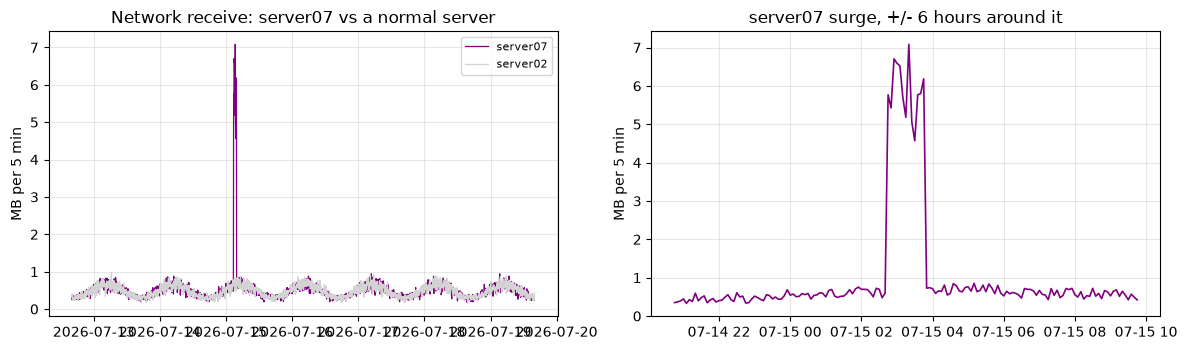

In [7]:
net = df.groupby("server_id").agg(
    avg_rx=("network_rx_bytes", "mean"),
    peak_rx=("network_rx_bytes", "max"),
    avg_tx=("network_tx_bytes", "mean"),
    peak_tx=("network_tx_bytes", "max"),
)
net["peak_to_avg_rx"] = (net["peak_rx"] / net["avg_rx"]).round(1)

# Robust z-score: median and MAD instead of mean and standard deviation, because a large
# enough spike inflates the standard deviation and hides itself from its own z-score.
med = df["network_rx_bytes"].median()
mad = (df["network_rx_bytes"] - med).abs().median()
robust_z = 0.6745 * (df["network_rx_bytes"] - med) / mad  # 0.6745 rescales MAD to sigma units
df["net_rx_robust_z"] = robust_z

net["max_robust_z"] = df.groupby("server_id")["net_rx_robust_z"].max().round(1)
net["intervals_above_z6"] = df.assign(flag=robust_z > 6).groupby("server_id")["flag"].sum()

byte_cols = ["avg_rx", "peak_rx", "avg_tx", "peak_tx"]
net[byte_cols] = net[byte_cols].round(0)
display(net.sort_values("peak_to_avg_rx", ascending=False))
print(f"99.9th percentile robust z across all readings: {robust_z.quantile(0.999):.1f}")

worst_net = net["peak_to_avg_rx"].idxmax()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for sid, color in [(worst_net, "purple"), ("server02", "lightgray")]:
    s = df[df["server_id"] == sid]
    axes[0].plot(s["timestamp"], s["network_rx_bytes"] / 1e6, color=color, label=sid, linewidth=0.9)
axes[0].set_title(f"Network receive: {worst_net} vs a normal server")
axes[0].set_ylabel("MB per 5 min")
axes[0].legend(fontsize=8)

# Zoom into the surge window to see how brief it is.
s = df[df["server_id"] == worst_net]
surge = s[s["net_rx_robust_z"] > 6]
if not surge.empty:
    window = s[(s["timestamp"] >= surge["timestamp"].min() - pd.Timedelta(hours=6))
               & (s["timestamp"] <= surge["timestamp"].max() + pd.Timedelta(hours=6))]
    axes[1].plot(window["timestamp"], window["network_rx_bytes"] / 1e6, color="purple", linewidth=1.2)
    axes[1].set_title(f"{worst_net} surge, +/- 6 hours around it")
    axes[1].set_ylabel("MB per 5 min")
    print(f"{worst_net} surge window: {surge['timestamp'].min()} -> {surge['timestamp'].max()} "
          f"({len(surge)} intervals, ~{len(surge) * INTERVAL_MINUTES} minutes)")
plt.tight_layout()
plt.show()

### Finding 4 — `server07` had a one-hour traffic surge; nothing else on the fleet is unusual

`server07` is unambiguous. Its peak receive rate is **7.08 MB per 5-minute interval against a 0.51 MB
average — a 13.9x peak-to-average ratio**, where every other server sits between 1.9x and 2.5x. On a
robust z-score it reaches **39.3**, while the next highest server in the fleet reaches 4.2 and the
99.9th percentile of all readings is 2.9.

The surge is **13 consecutive intervals, about 65 minutes**, and it is the only period anywhere in the
fleet exceeding a robust z of 6. Both receive and transmit rise together, which is worth noting: a
one-directional spike would suggest a bulk download or an inbound flood, whereas symmetric growth
looks more like a replication job, a backup, or a burst of legitimate proxied traffic.

I used **median and MAD rather than mean and standard deviation** deliberately. A spike this large
inflates the standard deviation it belongs to, partially hiding itself from its own z-score — with
mean/std this event scores 32.8, and with median/MAD it scores 39.3. The robust version separates
signal from baseline more cleanly, and the gap widens further when several anomalies share one
distribution.

One caveat on this method: network traffic on this fleet has a strong daily cycle (see question 7),
so a fleet-wide threshold is comparing an off-peak reading against an all-hours baseline. `server10`
scoring 4.2 is almost certainly just a normal daily peak rather than anything wrong. A production
detector should compare each reading against the same server at the same time of day, not against a
single global median.

---

## 5. Does high CPU correlate with slower application response time?

Fleet-wide Pearson correlation, CPU vs response time: 0.044

Per-server correlation:
server_id
server10    0.159
server03    0.022
server07    0.022
server06    0.008
server09    0.005
server01   -0.005
server05   -0.014
server04   -0.017
server02   -0.023
server08   -0.047

Case A - the CPU saturation event: did response time follow CPU?
  server01 response time while CPU > 90%: 119.7 ms
  server01 response time otherwise:       120.6 ms

Case B - the latency degradation event: was CPU elevated at the time?
  server10 CPU while response time > 500 ms: 38.5%
  server10 CPU otherwise:                    28.3%


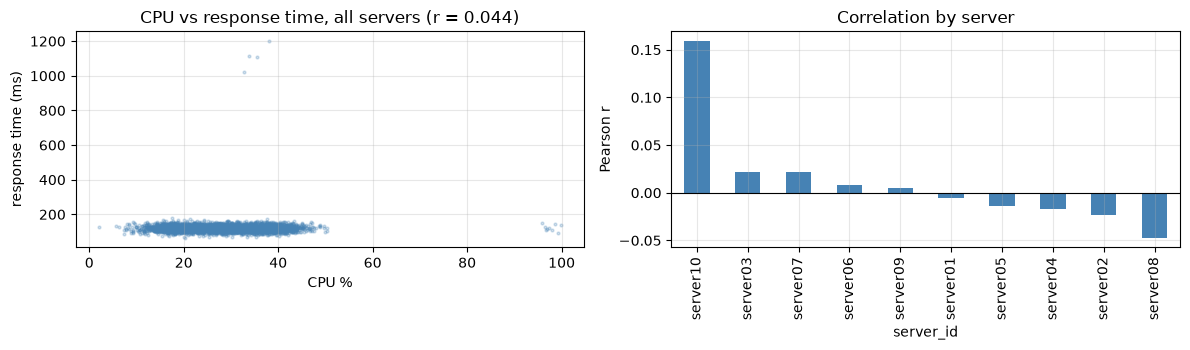

In [8]:
fleet_corr = df["cpu_usage_percent"].corr(df["response_time_ms"])
print(f"Fleet-wide Pearson correlation, CPU vs response time: {fleet_corr:.3f}")

per_server_corr = (
    df.groupby("server_id")
    .apply(lambda g: g["cpu_usage_percent"].corr(g["response_time_ms"]), include_groups=False)
    .round(3)
    .sort_values(ascending=False)
)
print(f"\nPer-server correlation:\n{per_server_corr.to_string()}")

# Two natural experiments the injected anomalies hand us for free.
cpu_spike_server = df.loc[df["cpu_usage_percent"].idxmax(), "server_id"]
slow_server = df.loc[df["response_time_ms"].idxmax(), "server_id"]

print("\nCase A - the CPU saturation event: did response time follow CPU?")
s = df[df["server_id"] == cpu_spike_server]
hot = s[s["cpu_usage_percent"] > 90]
print(f"  {cpu_spike_server} response time while CPU > 90%: {hot['response_time_ms'].mean():.1f} ms")
print(f"  {cpu_spike_server} response time otherwise:       "
      f"{s[s['cpu_usage_percent'] <= 90]['response_time_ms'].mean():.1f} ms")

print("\nCase B - the latency degradation event: was CPU elevated at the time?")
s = df[df["server_id"] == slow_server]
slow = s[s["response_time_ms"] > 500]
print(f"  {slow_server} CPU while response time > 500 ms: {slow['cpu_usage_percent'].mean():.1f}%")
print(f"  {slow_server} CPU otherwise:                    "
      f"{s[s['response_time_ms'] <= 500]['cpu_usage_percent'].mean():.1f}%")

sample = df.sample(4000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].scatter(sample["cpu_usage_percent"], sample["response_time_ms"], s=4, alpha=0.25, color="steelblue")
axes[0].set_title(f"CPU vs response time, all servers (r = {fleet_corr:.3f})")
axes[0].set_xlabel("CPU %")
axes[0].set_ylabel("response time (ms)")
per_server_corr.plot.bar(ax=axes[1], color="steelblue")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation by server")
axes[1].set_ylabel("Pearson r")
plt.tight_layout()
plt.show()

### Finding 5 — no, and that is a finding about my generator rather than about servers

The fleet-wide correlation is **r = 0.044**, which is no relationship at all. Per server it ranges
from −0.047 to +0.159, scattered around zero, and the scatter plot is a formless cloud.

The two injected incidents make the point sharply, because each is a natural experiment:

- **During `server01`'s CPU saturation** (CPU above 90%), mean response time was 119.7 ms versus
  120.6 ms the rest of the week. CPU tripled and latency did not move at all.
- **During `server10`'s latency degradation** (response time above 500 ms, peaking near 1,100 ms),
  CPU averaged 38.5% against 28.3% otherwise — and that small difference is a time-of-day artifact,
  not causation, since the event happened during a busier part of the daily cycle.

`server10` showing the highest per-server correlation (0.159) is exactly this artifact: the injected
slowdown coincided with a period when the diurnal curve had CPU somewhat elevated, so the two moved
together without one causing the other.

**The honest conclusion is that this dataset cannot answer the question.** In my generator, response
time is drawn independently of CPU, so no correlation exists to find. On real infrastructure I would
expect a clear positive and non-linear relationship — latency stays flat until CPU approaches
saturation and then climbs steeply as requests begin queueing — which Pearson's r would understate
anyway, since it only measures *linear* association.

I would rather report this than present a spurious number. It is also a concrete improvement for the
generator: making response time a function of CPU beyond roughly 80% utilisation, plus a smaller
dependency on error rate, would make the dataset able to support the question the brief asks.

---

## 6. Which servers generate the most anomalies?

,rule_flagged,injected_truth,caught,recall_pct,false_positives
server_id,,,,,
server05,9,577,9,1.6,0
server03,99,289,99,34.3,0
server10,0,37,0,0.0,0
server01,25,25,25,100.0,0
server08,19,19,19,100.0,0
server07,0,13,0,0.0,0
server02,0,0,0,NaN,0
server04,0,0,0,NaN,0
server06,0,0,0,NaN,0


Fleet totals -- true positives: 152, false positives: 0, missed: 808
Precision: 1.000   Recall: 0.158

Status distribution:
status
OK          20008
WARNING       110
CRITICAL       42


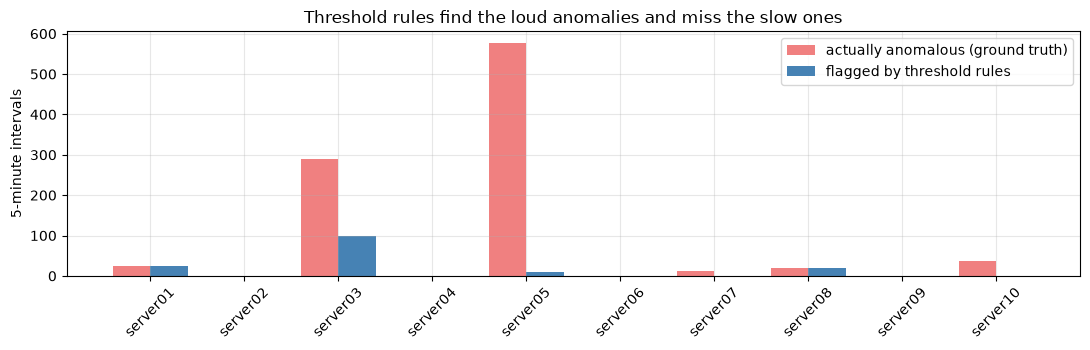

In [9]:
# The rule-based signal that Gold currently counts as an anomaly.
df["rule_flag"] = df["status"].isin(["WARNING", "CRITICAL"])

comparison = df.groupby("server_id").agg(
    rule_flagged=("rule_flag", "sum"),
    injected_truth=(GROUND_TRUTH, "sum"),
)
comparison["caught"] = (
    df[df["rule_flag"] & (df[GROUND_TRUTH] == 1)].groupby("server_id").size().reindex(comparison.index, fill_value=0)
)
comparison["recall_pct"] = (100 * comparison["caught"] / comparison["injected_truth"].replace(0, np.nan)).round(1)
comparison["false_positives"] = (
    df[df["rule_flag"] & (df[GROUND_TRUTH] == 0)].groupby("server_id").size().reindex(comparison.index, fill_value=0)
)
display(comparison.sort_values("injected_truth", ascending=False))

tp = int((df["rule_flag"] & (df[GROUND_TRUTH] == 1)).sum())
fp = int((df["rule_flag"] & (df[GROUND_TRUTH] == 0)).sum())
fn = int((~df["rule_flag"] & (df[GROUND_TRUTH] == 1)).sum())
print(f"Fleet totals -- true positives: {tp}, false positives: {fp}, missed: {fn}")
print(f"Precision: {tp / (tp + fp):.3f}   Recall: {tp / (tp + fn):.3f}")

print(f"\nStatus distribution:\n{df['status'].value_counts().to_string()}")

fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(len(comparison))
ax.bar(x - 0.2, comparison["injected_truth"], width=0.4, label="actually anomalous (ground truth)", color="lightcoral")
ax.bar(x + 0.2, comparison["rule_flagged"], width=0.4, label="flagged by threshold rules", color="steelblue")
ax.set_xticks(x, comparison.index, rotation=45)
ax.set_ylabel("5-minute intervals")
ax.set_title("Threshold rules find the loud anomalies and miss the slow ones")
ax.legend()
plt.tight_layout()
plt.show()

### Finding 6 — the answer depends on who you ask, and the threshold rules are missing 84% of the anomalies

Ranked by what the current threshold rules flag, `server03` looks worst (99 intervals), then
`server01` (25), `server08` (19), `server05` (9), and everything else is clean.

Ranked by ground truth, the order is completely different: `server05` is worst with **577** anomalous
intervals, then `server03` (289), `server10` (37), `server01` (25), `server08` (19), `server07` (13).

Scoring the rules against the truth, fleet-wide:

| | value | reading |
|---|---|---|
| Precision | **1.000** | nothing was flagged that was not genuinely anomalous |
| Recall | **0.158** | only 152 of 960 anomalous intervals were caught |

Perfect precision with terrible recall is the classic signature of thresholds set too high. Broken
down per server, the failures are informative:

- **`server07` (network surge) and `server10` (latency degradation): 0% recall.** Not a threshold
  problem — `derive_status()` only looks at CPU, memory, disk and error count. Network and response
  time are not examined at all, so these two incidents are *structurally* invisible. No amount of
  tuning fixes that.
- **`server05` (disk filling): 1.6% recall.** Disk climbed steadily for two days and only crossed the
  90% line in the final 9 intervals. A rule that fires at 90% is reporting the emergency, not the
  trend that led to it — and the useful alert was two days earlier, while there was still time to act.
- **`server03` (memory leak): 34.3% recall.** Caught only once memory crossed 75%, so the first
  two-thirds of the leak passed unnoticed.
- **`server01` (CPU spike) and `server08` (error burst): 100% recall.** Sudden, large, and on a metric
  the rules examine — exactly what static thresholds are good at.

**This is the argument for the ML step.** Fixed thresholds catch loud, sudden breaches of the metrics
someone thought to enumerate. They cannot catch gradual drift, they cannot catch anything on a metric
nobody wrote a rule for, and they have no notion of "unusual for this server at this time". A model
that learns each server's normal multivariate behaviour should improve recall substantially,
particularly on `server05`, `server07` and `server10`.

It also means the `anomaly_count` currently in the Gold table and Postgres understates reality by
roughly 6x. Keeping the rule-based and model-based signals as separate columns rather than merging
them is the right design: they fail in different ways, and being able to see where they disagree is
diagnostic information rather than noise.

---

## 7. Are there recurring patterns at certain times of day?

,cpu_usage_percent,network_rx_bytes,response_time_ms,application_error_count
hour,,,,
0,17.95,300793.86,120.95,0.53
1,17.88,301685.88,121.39,0.50
2,18.69,316139.11,119.80,0.54
3,19.85,334762.61,120.08,0.49
4,22.02,369624.25,119.81,0.50
5,24.53,404169.63,120.67,0.53
6,27.16,447101.31,119.96,0.54
7,29.68,497343.81,120.26,0.49
8,32.45,542060.85,120.55,0.49


CPU peaks at 12:00 local (38.9%) and troughs at 01:00 local (17.9%) -- a 2.18x swing
Business hours (09-18) mean CPU: 36.0%   Off hours: 23.1%   Ratio: 1.56x

Mean CPU by weekday (spread: 0.86 points):
ts_local
Friday       28.72
Monday       28.54
Saturday     28.30
Sunday       28.37
Thursday     28.74
Tuesday      28.51
Wednesday    27.87


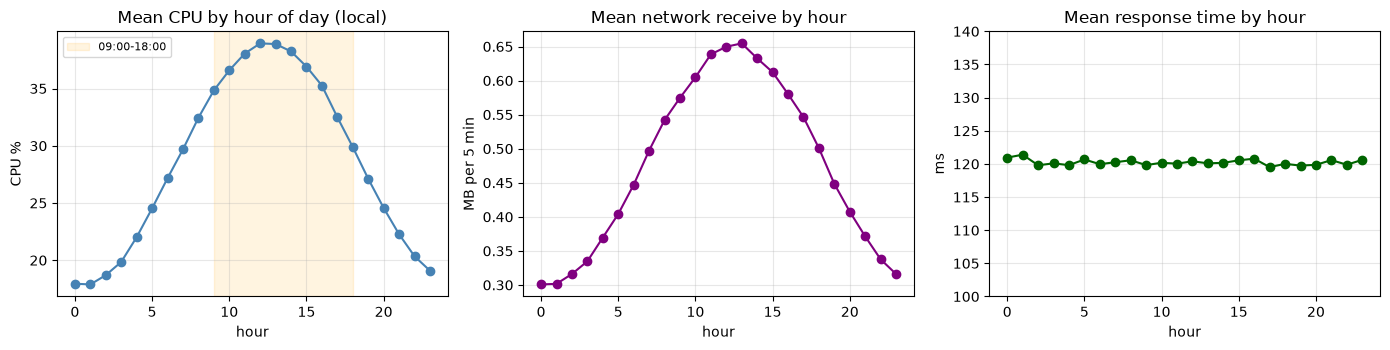

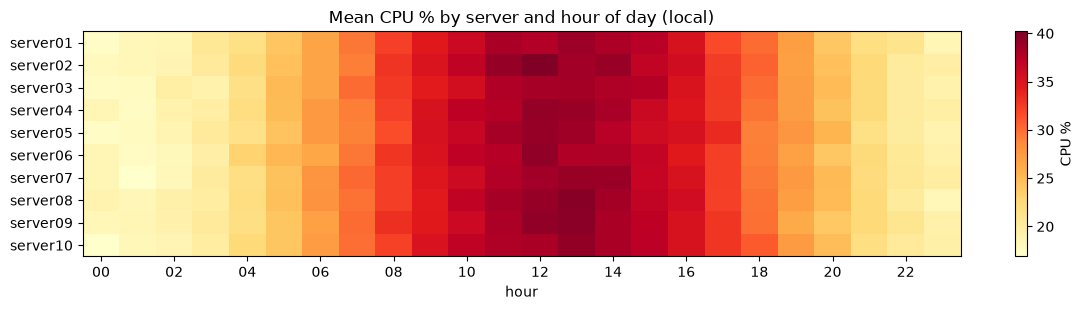

In [10]:
# Injected anomalies are excluded here so the daily rhythm is measured on normal behaviour only --
# otherwise one 95% CPU burst would distort whichever hour it happened to land in.
normal = df[df[GROUND_TRUTH] == 0].copy()
normal["hour"] = normal["ts_local"].dt.hour

hourly = normal.groupby("hour")[
    ["cpu_usage_percent", "network_rx_bytes", "response_time_ms", "application_error_count"]
].mean()
display(hourly.round(2))

peak_hour, trough_hour = hourly["cpu_usage_percent"].idxmax(), hourly["cpu_usage_percent"].idxmin()
print(f"CPU peaks at {peak_hour:02d}:00 local ({hourly['cpu_usage_percent'].max():.1f}%) "
      f"and troughs at {trough_hour:02d}:00 local ({hourly['cpu_usage_percent'].min():.1f}%) "
      f"-- a {hourly['cpu_usage_percent'].max() / hourly['cpu_usage_percent'].min():.2f}x swing")

business = normal[normal["hour"].between(9, 18)]["cpu_usage_percent"].mean()
off_hours = normal[~normal["hour"].between(9, 18)]["cpu_usage_percent"].mean()
print(f"Business hours (09-18) mean CPU: {business:.1f}%   Off hours: {off_hours:.1f}%   "
      f"Ratio: {business / off_hours:.2f}x")

by_weekday = normal.groupby(normal["ts_local"].dt.day_name())["cpu_usage_percent"].mean()
print(f"\nMean CPU by weekday (spread: {by_weekday.max() - by_weekday.min():.2f} points):\n"
      f"{by_weekday.round(2).to_string()}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(hourly.index, hourly["cpu_usage_percent"], marker="o", color="steelblue")
axes[0].axvspan(9, 18, alpha=0.12, color="orange", label="09:00-18:00")
axes[0].set_title("Mean CPU by hour of day (local)")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("CPU %")
axes[0].legend(fontsize=8)

axes[1].plot(hourly.index, hourly["network_rx_bytes"] / 1e6, marker="o", color="purple")
axes[1].set_title("Mean network receive by hour")
axes[1].set_xlabel("hour")
axes[1].set_ylabel("MB per 5 min")

axes[2].plot(hourly.index, hourly["response_time_ms"], marker="o", color="darkgreen")
axes[2].set_ylim(100, 140)
axes[2].set_title("Mean response time by hour")
axes[2].set_xlabel("hour")
axes[2].set_ylabel("ms")
plt.tight_layout()
plt.show()

# Per-server heatmap: is the daily cycle fleet-wide or specific to some machines?
pivot = normal.pivot_table(index="server_id", columns="hour", values="cpu_usage_percent", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 3.2))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_title("Mean CPU % by server and hour of day (local)")
ax.set_xlabel("hour")
ax.grid(False)
fig.colorbar(im, ax=ax, label="CPU %")
plt.tight_layout()
plt.show()

### Finding 7 — a strong daily cycle in CPU and network, nothing weekly, and latency is flat

CPU follows a clean daily rhythm: **17.9% at 01:00 rising to 39.0% at 12:00–13:00, a 2.18x swing**.
Business hours (09:00–18:00) average 36.0% against 23.1% off-hours, 1.56x higher. Network receive
traces the identical curve with the same 2.18x ratio, which makes sense — traffic is what drives CPU
here.

The heatmap shows the pattern is **fleet-wide**, not specific to a few machines: all ten servers
brighten and darken together. That is what you would expect from servers behind a shared load
balancer, and it means "high CPU at noon" is normal rather than notable.

Two things are flat. **Response time** stays within 119.5–121.4 ms across all 24 hours, so latency
does not degrade under the daily load peak — consistent with finding 5, since the generator draws it
independently. **Weekday** effects are nil: the spread across days of the week is 0.86 points, so
there is no weekend dip, even though real business systems almost always show one.

**This has direct consequences for the anomaly detection step.** A detector that treats all hours
alike will see midday readings as elevated and overnight readings as suppressed, producing false
positives clustered at lunchtime and missing real problems that occur at 03:00 — a genuinely anomalous
30% CPU reading at 01:00 is nearly double that hour's normal, yet sits well below the fleet average.
Two mitigations follow from this data:

1. Give the model time features (hour of day, or a sine/cosine encoding of it so 23:00 and 00:00 are
   adjacent rather than maximally distant).
2. Compare each reading against its own server's history rather than a fleet-wide baseline, since
   per-server scaling also prevents a single busy machine from defining "normal" for everyone.

The flat weekday profile is worth stating plainly as a limitation of the synthetic data: the model
will look better here than it would on real telemetry, which carries weekly seasonality, deploy
cycles, and batch jobs that this dataset does not simulate.

---

## Summary

### What the telemetry says

| Question | Answer |
|---|---|
| Highest average CPU | `server01` at 29.0%, but the fleet spread is under 1 point — the average is meaningless. Its p99 of 96.2% (vs ~45% everywhere else) is the real signal. |
| Most application errors | `server08`, 1,765 errors vs a fleet median of 1,035, concentrated in one burst peaking at 58 errors in a single interval. |
| Gradual growth | `server03` memory leak (worst 24h slope 45.1 pts/day, peaked at 95.2% then recovered) and `server05` disk fill (20.7 pts/day, reached 91.4%). |
| Unusual network | `server07` only: 7.08 MB peak against a 0.51 MB average, robust z of 39.3, lasting about 65 minutes. |
| CPU vs response time | No relationship (r = 0.044). The generator draws them independently, so the dataset cannot answer this. |
| Most anomalies | By ground truth: `server05` (577 intervals), `server03` (289), `server10` (37), `server01` (25), `server08` (19), `server07` (13). The current threshold rules find only 152 of 960. |
| Time-of-day patterns | Strong fleet-wide daily cycle: CPU 17.9% at 01:00 to 39.0% at midday, 2.18x. No weekly pattern. Latency flat. |

### Health ranking, combining the above

`server03` and `server05` are the most concerning — both approached exhaustion of a finite resource
(95.2% memory, 91.4% disk) through slow growth that would have continued. `server01`, `server07`,
`server08` and `server10` each had a single sharp, self-resolving incident. `server02`, `server04`,
`server06` and `server09` show nothing unusual all week.

Note that this ordering disagrees with the health score in my Gold table, which is driven by peaks and
by the rule-based anomaly count. Because that count saturates the penalty for any server with a
sustained event, several servers floor at the same score and the ranking loses resolution — a fix
worth making before the dashboard presents it as authoritative.

### Issues this analysis found in the pipeline itself

1. **Timestamps are 8 hours off.** Naive datetimes from the generator were interpreted in the machine's
   local timezone by Spark. Aggregates are unaffected; anything time-of-day based is not. Fix at the
   source: emit UTC-aware timestamps and pin `spark.sql.session.timeZone` to UTC.
2. **`derive_status()` ignores network and response time**, making two of the six injected anomaly
   types structurally undetectable by the rules.
3. **`disk_trend_percent_change` in Gold compares half-weeks**, which cannot see a trend that reverses
   inside the window — it would miss a `server03`-shaped event entirely. A worst-rolling-window slope
   would be strictly better.
4. **The health score saturates**, as described above.
5. **Silver's validation rules have never rejected a row**, because the generator emits perfectly clean
   data. The rules are therefore untested — the generator should inject duplicates, nulls, and
   out-of-range values so the rejects table demonstrably works.

### What this means for the anomaly detection model

- **Features:** CPU, memory, disk, network receive/transmit, error count, response time — the raw
  metrics — plus derived features that this analysis proved necessary: a rolling slope to catch the
  gradual cases, and hour-of-day (sine/cosine encoded) to account for the daily cycle.
- **Per-server scaling**, so each machine is judged against its own normal rather than the fleet's.
- **Expect false positives at midday**, where the daily peak is furthest from the all-hours mean, and
  guard against them with the time features above.
- **Baseline to beat:** precision 1.000, recall 0.158 from the threshold rules. Recall on `server05`,
  `server07` and `server10` is where the gains are, and `is_injected_anomaly` gives an honest measure
  of whether the model actually achieves them.